#  Data Science Project 2: Supervised Learning (Fraud Detection Pipeline)

**Internship Domain:** Data Science  
**Powered by:** DecodeLabs  
**Dataset:** Credit Card Fraud Detection (Highly Imbalanced)  

### Project Goals Achieved:
* **Zero Data Leakage:** Used `imblearn.pipeline` to strictly isolate resampling within Cross-Validation.
* **Algorithmic Precision:** Implemented SMOTE for synthetic minority over-sampling instead of mere duplication.
* **Robust Modeling:** Trained Logistic Regression (with scaling) and Random Forest (scale-invariant) using `GridSearchCV`.
* **Strict Evaluation:** Discarded 'Accuracy' and evaluated models using Precision, Recall, and ROC-AUC.
---

In [1]:

# Importing Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

# Scikit-Learn for modeling, splitting, and metrics
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score


In [3]:

# Imblearn for SMOTE and Pipeline to prevent Data Leakage
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

#import warnings
#warnings.filterWarning('ignore') # Hiding unnecessary warnings (Faltu warnings ko chupane ke liye)
print("All libraries imported successfully!")


All libraries imported successfully!


In [4]:

# Load the dataset 
df = pd.read_csv('creditcard.csv')


In [5]:

# Display the first 5 rows of the dataset to get a quick overview of the data structure and values
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:

# Display the last 5 rows of the dataset to verify the end of the data and check for any trailing inconsistencies
df.tail()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [7]:

# Generate a statistical summary of the numerical columns in the dataset (includes count, mean, standard deviation, min, max, and quartiles)
df.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:

# Display a concise summary of the dataset, including column names, data types, and the count of non-null values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
print("Dataset Shape :", df.shape)

Dataset Shape : (284807, 31)


In [10]:

# Check the distribution of the target variable 'Class'
# (Target column 'Class' mein fraud aur legitimate ka farq dekhein)
class_counts = df['Class'].value_counts()
legit_rate = (class_counts[0] / len(df)) * 100
fraud_rate = (class_counts[1] / len(df)) * 100

print(f"\nLegitimate Transactions (True transactions): {class_counts[0]} ({legit_rate:.2f}%)")
print(f"Fraudulent Transactions (False transactions): {class_counts[1]} ({fraud_rate:.2f}%)")

print("\nConclusion: The dataset is highly imbalanced. Accuracy metric must be discarded!")



Legitimate Transactions (True transactions): 284315 (99.83%)
Fraudulent Transactions (False transactions): 492 (0.17%)

Conclusion: The dataset is highly imbalanced. Accuracy metric must be discarded!


In [11]:

# Train/Test Split BEFORE applying SMOTE (Zero-Leakage Protocol)

X = df.drop('Class', axis=1)
y = df['Class']

# Stratified Split ensures exact class ratios in both sets
# (Stratified split se dono sets mein fraud ka ratio same rehta hai)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)
print("Data successfully split. Validation fold is strictly protected!")


Training Set Shape: (227845, 30)
Testing Set Shape: (56962, 30)
Data successfully split. Validation fold is strictly protected!


In [12]:

# Logistic Regression Pipeline with StandardScaler and SMOTE

print("Constructing Logistic Regression Pipeline...")

# Pipeline construction 
lr_pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),       # Step 1: Scale data (Data ko scale karna)
    ('smote', SMOTE(random_state=42)),  # Step 2: Synthetic Balancing (SMOTE se balance karna)
    ('classifier', LogisticRegression(max_iter=1000)) # Step 3: Engine (Model lagana)
])

# Hyperparameter grid based on DecodeLabs instructions

lr_param_grid = {
    'smote__k_neighbors': [3, 5, 7],
    'classifier__C': [0.01, 0.1, 1.0]
}

# 5-Fold Cross Validation (5 hisson mein data test karna)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV optimizes strictly inside the folds to prevent leakage
lr_grid = GridSearchCV(lr_pipeline, lr_param_grid, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)

print("Training Logistic Regression Model (Takes a few minutes)... ")
lr_grid.fit(X_train, y_train)

print(f"Best LR Parameters (Sab se behtareen parameters): {lr_grid.best_params_}")
print(f"Best LR CV ROC-AUC Score: {lr_grid.best_score_:.4f}")


Constructing Logistic Regression Pipeline...
Training Logistic Regression Model (Takes a few minutes)... 
Best LR Parameters (Sab se behtareen parameters): {'classifier__C': 0.01, 'smote__k_neighbors': 5}
Best LR CV ROC-AUC Score: 0.9807


In [13]:

# Random Forest Pipeline with SMOTE (No Scaling Required)
# Random forest scale-invariant hai, isme StandardScaler nahi lagega.

print("Constructing Random Forest Pipeline...")

# Ensemble Tree Scoring (Tree-based model pipeline)
rf_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)), # Step 1: Balancing (SMOTE lagana)
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1)) # Step 2: Engine (Random Forest lagana)
])

# Hyperparameter grid based on DecodeLabs instructions

rf_param_grid = {
    'smote__k_neighbors': [3, 5, 7],
    'classifier__max_depth': [10, 20, None]
}

# GridSearchCV
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)

print("Training Random Forest Model (This will take time due to large data)...")
rf_grid.fit(X_train, y_train)

print(f"Best RF Parameters (Sab se behtareen parameters): {rf_grid.best_params_}")
print(f"Best RF CV ROC-AUC Score: {rf_grid.best_score_:.4f}")


Constructing Random Forest Pipeline...
Training Random Forest Model (This will take time due to large data)...
Best RF Parameters (Sab se behtareen parameters): {'classifier__max_depth': 10, 'smote__k_neighbors': 3}
Best RF CV ROC-AUC Score: 0.9837


--- Final Evaluation for Logistic Regression ---
ROC-AUC Score: 0.9715 (Model's capability to separate distributions)
Precision: 0.0585 (When flagged as fraud, is it right?)
Recall: 0.9184 (Did we catch all the fraud?)

Confusion Matrix:


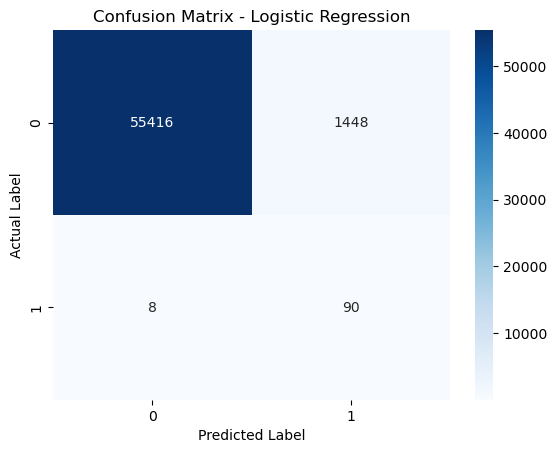

--- Final Evaluation for Random Forest ---
ROC-AUC Score: 0.9829 (Model's capability to separate distributions)
Precision: 0.5548 (When flagged as fraud, is it right?)
Recall: 0.8776 (Did we catch all the fraud?)

Confusion Matrix:


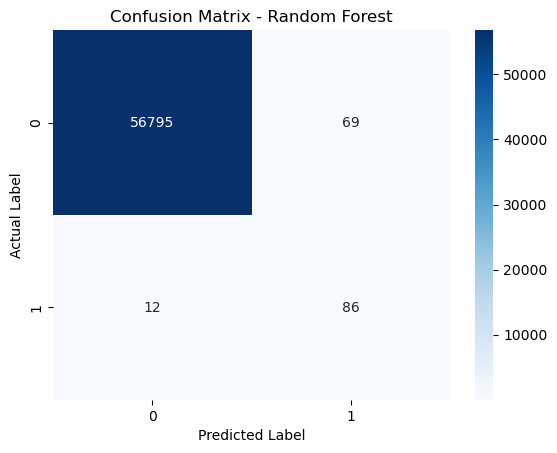


Pipeline execution complete with absolute algorithmic precision!


In [14]:

# Final Evaluation using strict metrics (Precision, Recall, ROC-AUC)
# Accuracy ko reject karte hue asal metrics (Precision, Recall, ROC-AUC) par test karna.

def evaluate_model(model, name, X_test, y_test):
    print(f"--- Final Evaluation for {name} ---")
    
    # Predictions (Model ki pishangoi)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate strict metrics (Metrics calculate karna)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    print(f"ROC-AUC Score: {roc_auc:.4f} (Model's capability to separate distributions)")
    print(f"Precision: {precision:.4f} (When flagged as fraud, is it right?)")
    print(f"Recall: {recall:.4f} (Did we catch all the fraud?)")
    
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Evaluate both optimized models
# (Dono models ko evaluate karna)
evaluate_model(lr_grid.best_estimator_, "Logistic Regression", X_test, y_test)
evaluate_model(rf_grid.best_estimator_, "Random Forest", X_test, y_test)

print("\nPipeline execution complete with absolute algorithmic precision!")
